In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

In [45]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [47]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [48]:
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

In [49]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [50]:
df = df.drop('id', axis=1)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


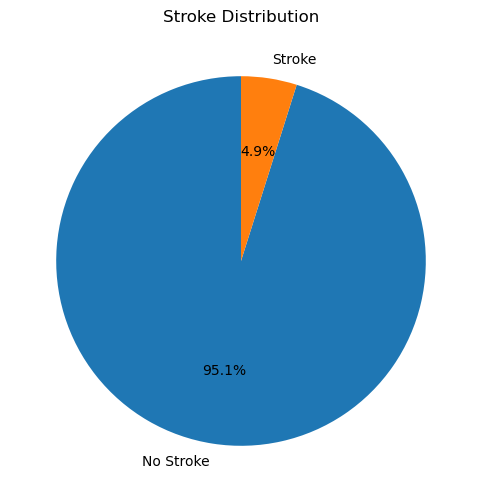

In [51]:
stroke_counts = df['stroke'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    stroke_counts,
    labels=['No Stroke', 'Stroke'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Stroke Distribution")
plt.show()

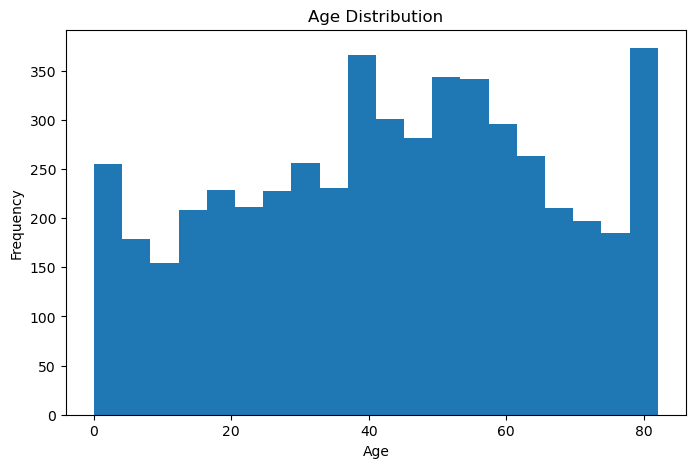

In [52]:
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

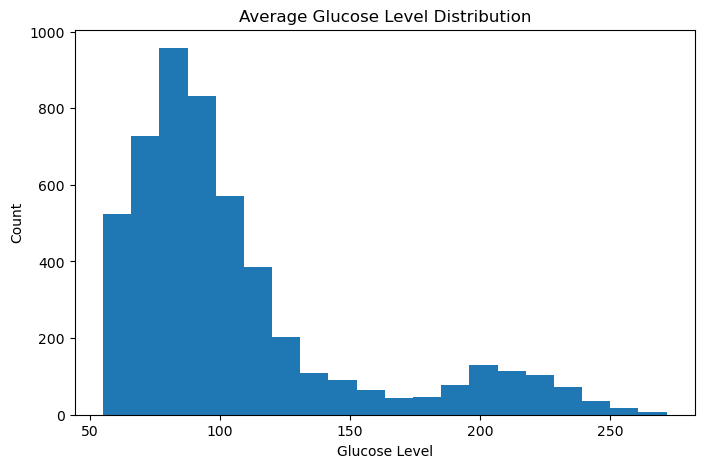

In [53]:
plt.figure(figsize=(8,5))
plt.hist(df['avg_glucose_level'], bins=20)
plt.title("Average Glucose Level Distribution")
plt.xlabel("Glucose Level")
plt.ylabel("Count")
plt.show()

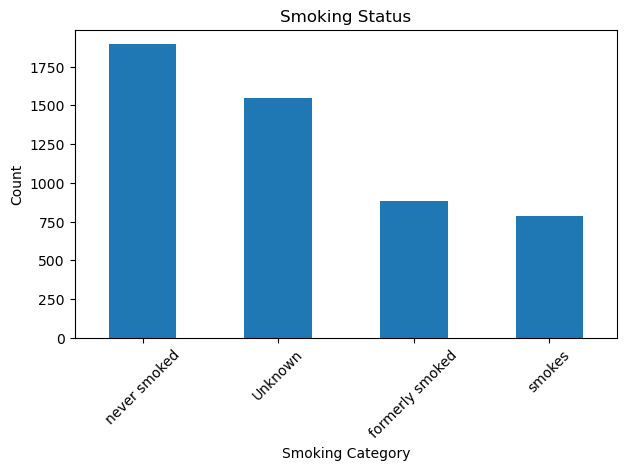

In [54]:
plt.figure(figsize=(7,4))
df['smoking_status'].value_counts().plot(kind='bar')
plt.title("Smoking Status")
plt.xlabel("Smoking Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

<Figure size 600x400 with 0 Axes>

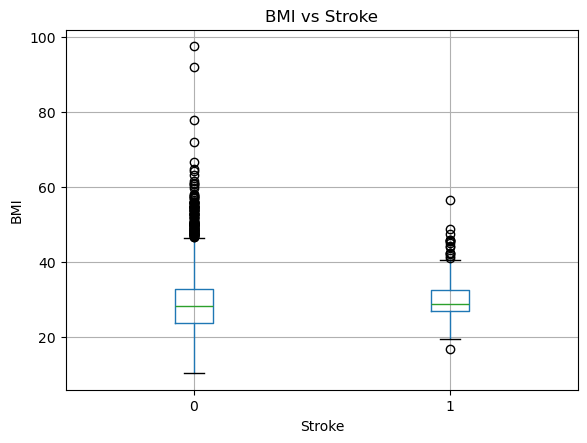

In [55]:
plt.figure(figsize=(6,4))
df.boxplot(column='bmi', by='stroke')
plt.title("BMI vs Stroke")
plt.suptitle("")
plt.xlabel("Stroke")
plt.ylabel("BMI")
plt.show()

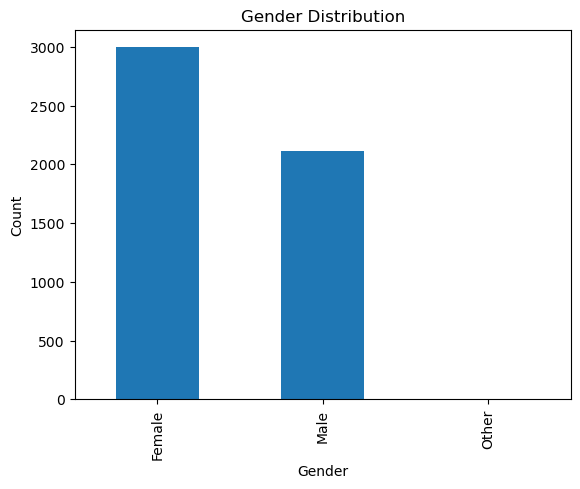

In [56]:
df['gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

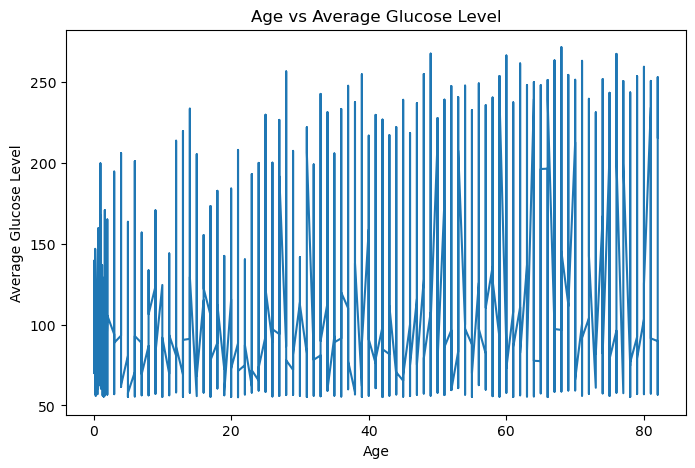

In [57]:
sorted_df = df.sort_values('age')
plt.figure(figsize=(8,5))
plt.plot(sorted_df['age'], sorted_df['avg_glucose_level'])
plt.title("Age vs Average Glucose Level")
plt.xlabel("Age")
plt.ylabel("Average Glucose Level")
plt.show()

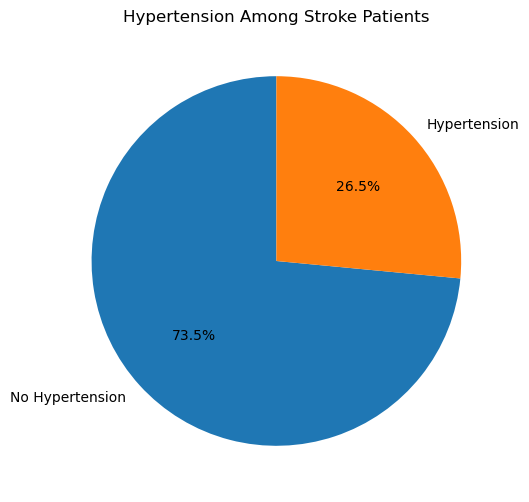

In [58]:
stroke_hyper = df[df['stroke'] == 1]['hypertension'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    stroke_hyper,
    labels=['No Hypertension', 'Hypertension'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Hypertension Among Stroke Patients")
plt.show()

In [59]:
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['ever_married'] = le.fit_transform(df['ever_married'])
df['work_type'] = le.fit_transform(df['work_type'])
df['Residence_type'] = le.fit_transform(df['Residence_type'])
df['smoking_status'] = le.fit_transform(df['smoking_status'])
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.600000,1,1
1,0,61.0,0,0,1,3,0,202.21,28.893237,2,1
2,1,80.0,0,1,1,2,0,105.92,32.500000,2,1
3,0,49.0,0,0,1,2,1,171.23,34.400000,3,1
4,0,79.0,1,0,1,3,0,174.12,24.000000,2,1


In [60]:
X = df.drop('stroke', axis=1)
y = df['stroke']

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [62]:
model = DecisionTreeClassifier(class_weight='balanced',random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [63]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(1022,))

In [64]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9217221135029354


In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       960
           1       0.25      0.15      0.18        62

    accuracy                           0.92      1022
   macro avg       0.60      0.56      0.57      1022
weighted avg       0.90      0.92      0.91      1022



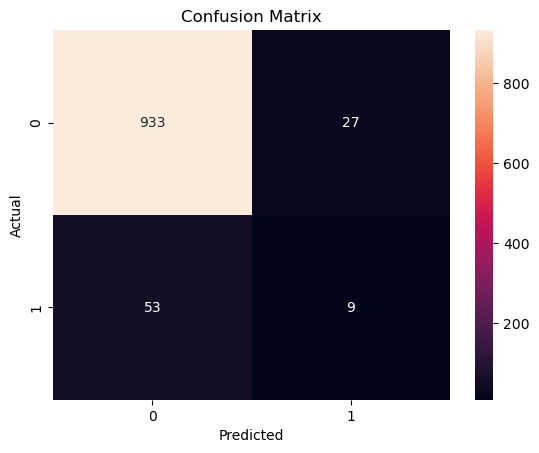

In [70]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [71]:
# Example unseen patient data (same format as dataset)
new_data = pd.DataFrame({
    'gender': [1],              # encoded value
    'age': [67],
    'hypertension': [0],
    'heart_disease': [1],
    'ever_married': [1],
    'work_type': [2],
    'Residence_type': [1],
    'avg_glucose_level': [228.69],
    'bmi': [36.6],
    'smoking_status': [1]
})

# Predict
prediction = model.predict(new_data)

# Output result
if prediction[0] == 1:
    print("Patient is likely to have a STROKE (1)")
else:
    print("Patient is NOT likely to have a stroke (0)")

Patient is likely to have a STROKE (1)
